In [1]:
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from langgraph.graph import StateGraph,START,END
from langchain_openai import AzureChatOpenAI
from langgraph.graph import add_messages
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain.agents import create_agent
from pydantic import BaseModel
import os
load_dotenv()

llm = AzureChatOpenAI(
    azure_deployment=os.environ["AZURE_OPENAI_CHAT_DEPLOYMENT_NAME"],
    api_version=os.environ["AZURE_OPENAI_API_VERSION"],
)


class FilePlan(BaseModel):
    filename: str
    description: str

class Plan(BaseModel):
    files: list[FilePlan]

class State(TypedDict):
    messages: Annotated[list, add_messages]
    plan: Plan
    code: dict

def planner_node(state: State):
    print("planner started")
    system_prompt = """
You are an expert software architect in python.

Given a user query, design a MINIMAL application.
ALWAYS include a README.md file with description and instructions to run the app.
Return a list of files with:
- filename
- description

Keep it simple and as minimal as possible.
"""

    messages = [
        {"role": "system", "content": system_prompt},
        *state["messages"]
    ]

    llm_structured = llm.with_structured_output(Plan)

    response = llm_structured.invoke(messages)
    print("planner ended")
    return {
        "plan": response,
        "messages": state["messages"] + [
            {"role": "assistant", "content": f"Plan created: {response}"}
        ]
    }

def worker_node(state: State):
    print("worker started")
    system_prompt = system_prompt = """
You are a senior software engineer.

Generate clean working code in python.

STRICT RULES:
- Only ASCII characters
- No emojis
- No special unicode symbols
- Return ONLY code
"""

    code_outputs = {}

    file_count = 1
    print(f"total files {len(state["plan"].files)}")
    for file in state["plan"].files:
        print(f"file {file_count} is getting coded")
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": f"""
File: {file.filename}
Description: {file.description}
"""}
        ]

        response = llm.invoke(messages)
    
        code_outputs[file.filename] = response.content

        file_count += 1


    print("worker ended")
    return {
        "code": code_outputs,
        "messages": state["messages"] + [
            {"role": "assistant", "content": "Code generated"}
        ]
    }

# def creator_node(state: State):
#     print("creator started")
#     base_dir = "generated_app"
#     os.makedirs(base_dir, exist_ok=True)
#     file_count = 1
#     for filename, code in state["code"].items():
#         print(f"file {file_count} is getting created")
#         file_path = os.path.join(base_dir, filename)

#         with open(file_path, "w", encoding="utf-8") as f:
#             f.write(code)
#         file_count += 1
#     print("creator ended")
#     return {
#         "messages": state["messages"] + [
#             {"role": "assistant", "content": "Files created successfully"}
#         ]
#     }

#ai generated code with better guardrails
def creator_node(state: State):

    print("📁 Creator started...")

    base_dir = "generated_app"
    os.makedirs(base_dir, exist_ok=True)

    for filename, code in state["code"].items():

        clean_filename = filename.strip().replace("\n", "")
        file_path = os.path.join(base_dir, clean_filename)

        print(f"   📄 Creating: {clean_filename}")

        # 🔥 Fix: ensure directories exist
        os.makedirs(os.path.dirname(file_path), exist_ok=True)

        with open(file_path, "w", encoding="utf-8") as f:
            f.write(str(code))

    print("✅ Creator finished")

    return {
        "messages": state["messages"] + [
            {"role": "assistant", "content": "Files created successfully"}
        ]
    }


builder = StateGraph(State)

builder.add_node("planner", planner_node)
builder.add_node("worker", worker_node)
builder.add_node("creator", creator_node)

builder.add_edge(START, "planner")
builder.add_edge("planner", "worker")
builder.add_edge("worker", "creator")
builder.add_edge("creator", END)

graph = builder.compile()


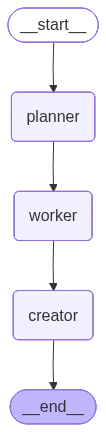

In [2]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))